# EDA: Per-Epoch Metrics & Final Test Performance

Skenario 1 = Train 204 / Val 26 / Test 26 | Skenario 2 = Train 178 / Val 52 / Test 26


In [17]:
%pip install matplotlib numpy pandas ipython
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
})


Note: you may need to restart the kernel to use updated packages.


## Figure 1 -- Sample Preprocessing Pipeline (Class: `cancer`)

To ensure compatibility with the selected pre-trained models, all images
underwent a standard preprocessing pipeline. The images were uniformly
resized to a resolution of 224x224 pixels and normalized using ImageNet
channel statistics. To mitigate the risk of overfitting inherent in small
datasets, data augmentation was exclusively applied to the training set.
The augmentation techniques included Random Horizontal Flip and Random
Rotation within a 15 degree range. The validation and test sets were
strictly kept in their original geometric state, undergoing only resizing
and normalization.

**Fig. 1.** A representative sample from the `cancer` class shown across
four stages of the preprocessing pipeline.


Sample: 0.jpg


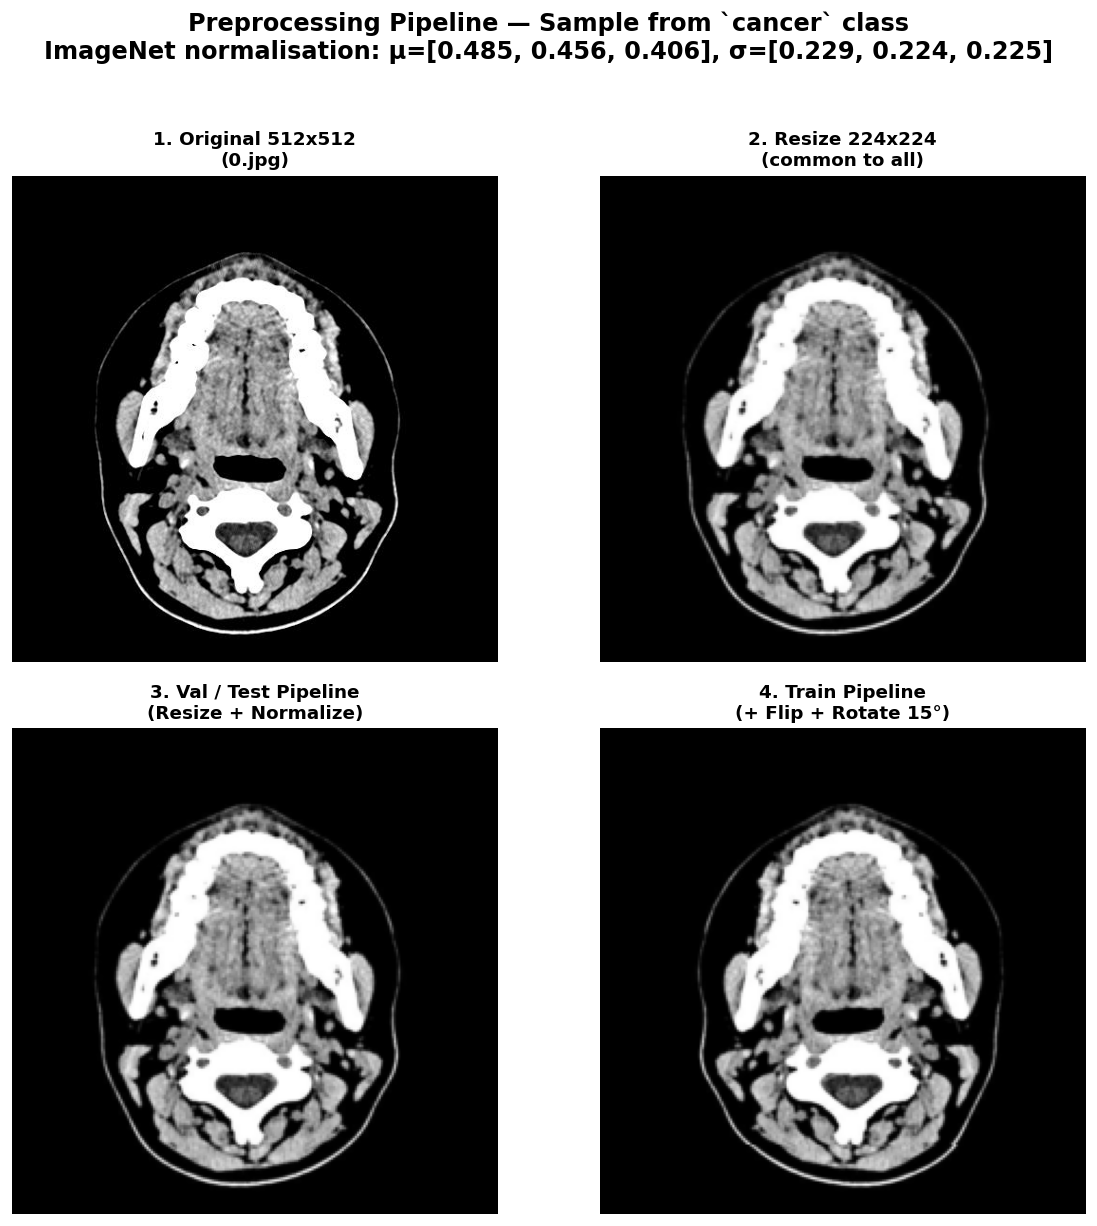

In [18]:
# ============================================================
# FIGURE 1 -- Sample Preprocessing Pipeline (Class: cancer)
# ============================================================
import os, random
from PIL import Image

import torch
from torchvision import transforms

# ---- Pick a random cancer sample ------------------------------------
# random.seed(42)
sample_file = '0.jpg'
img_path = os.path.join('./dataset/files/cancer', sample_file)
print(f'Sample: {sample_file}')

# ---- Transform pipelines (IDENTICAL to training notebooks) ----------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

resize_only = transforms.Resize((224, 224))

# ---- Load all 4 stages ----------------------------------------------
original     = Image.open(img_path).convert('RGB')
resized      = resize_only(original)
tensor_test  = test_transform(original)
tensor_train = train_transform(original)

# ---- Denormalise for human-viewable display -------------------------
def denorm(t):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1)

# ---- Plot (2 rows x 2 cols) ----------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

stages = [
    (original, f'1. Original 512x512\n({sample_file})'),
    (resized, '2. Resize 224x224\n(common to all)'),
    (denorm(tensor_test).permute(1, 2, 0),
     '3. Val / Test Pipeline\n(Resize + Normalize)'),
    (denorm(tensor_train).permute(1, 2, 0),
     '4. Train Pipeline\n(+ Flip + Rotate 15°)'),
]

# flatten biar gampang di-loop
axes = axes.flatten()

for ax, (img, title) in zip(axes, stages):
    ax.imshow(img)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.axis('off')

plt.suptitle(
    'Preprocessing Pipeline — Sample from `cancer` class\n'
    'ImageNet normalisation: μ=[0.485, 0.456, 0.406], σ=[0.229, 0.224, 0.225]',
    fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('fig1_cancer_preprocessing.png', dpi=150, bbox_inches='tight')
plt.show()


## Figure 3 — Log-scale Training Loss Trajectories under Aggressive Learning Rate ($\mathbf{LR = 10^{-2}}$)

**Fig. 3.** Log-scale Training Loss Trajectories under Aggressive Learning Rate (LR = $10^{-2}$).
Subfigures (a) Scenario 1 and (b) Scenario 2 showcase VGG16 exploding loss curves,
ResNet50 oscillations, and ViT stagnation.


In [19]:
# ============================================================
# DATA PARSER — extract real per-epoch metrics from training notebooks
# ============================================================
import json, re, numpy as np
from pathlib import Path

NOTEBOOKS = {
    ('skenario_1', '1e-2', 'VGG16'):    'skenario_1/train_vgg16_1e2.ipynb',
    ('skenario_1', '1e-2', 'ResNet50'): 'skenario_1/train_resnet50_1e2.ipynb',
    ('skenario_1', '1e-2', 'ViT'):      'skenario_1/train_vit_1e2.ipynb',
    ('skenario_2', '1e-2', 'VGG16'):    'skenario_2/train_vgg16_1e2.ipynb',
    ('skenario_2', '1e-2', 'ResNet50'): 'skenario_2/train_resnet50_1e2.ipynb',
    ('skenario_2', '1e-2', 'ViT'):      'skenario_2/train_vit_1e2.ipynb',
    ('skenario_1', '1e-4', 'VGG16'):    'skenario_1/train_vgg16_1e4.ipynb',
    ('skenario_1', '1e-4', 'ResNet50'): 'skenario_1/train_resnet50_1e4.ipynb',
    ('skenario_1', '1e-4', 'ViT'):      'skenario_1/train_vit_1e4.ipynb',
    ('skenario_2', '1e-4', 'VGG16'):    'skenario_2/train_vgg16_1e4.ipynb',
    ('skenario_2', '1e-4', 'ResNet50'): 'skenario_2/train_resnet50_1e4.ipynb',
    ('skenario_2', '1e-4', 'ViT'):      'skenario_2/train_vit_1e4.ipynb',
}

METRICS = {}  # METRICS[scenario][lr][model] = {'train_loss':[30], 'val_acc':[30]}

def _extract(nb_path):
    nb = json.loads(Path(nb_path).read_text(encoding='utf-8'))
    train_loss, val_acc = [], []
    for cell in nb['cells']:
        if cell['cell_type'] != 'code':
            continue
        src = ''.join(cell['source'])
        if 'epoch_train_loss' not in src:
            continue
        texts = []
        for o in cell.get('outputs', []):
            if o.get('output_type') == 'stream' and o.get('name') == 'stdout':
                texts.extend(o.get('text', []))
        combined = ''.join(texts)
        for line in combined.splitlines():
            m = re.search(r'Train Loss:\s*([\d.]+(?:e[+-]?\d+)?)', line)
            if m:
                train_loss.append(float(m.group(1)))
            m = re.search(r'Val Acc:\s*([\d.]+(?:e[+-]?\d+)?)', line)
            if m:
                val_acc.append(float(m.group(1)))
        break
    return train_loss, val_acc

for (scenario, lr, model), path in NOTEBOOKS.items():
    tl, va = _extract(path)
    METRICS.setdefault(scenario, {}).setdefault(lr, {})[model] = {
        'train_loss': tl, 'val_acc': va
    }
    print(f'{scenario} lr={lr} {model}: loss={len(tl)} epochs, val_acc={len(va)} epochs')

print('\nMETRICS ready — all 12 training notebooks parsed.')


skenario_1 lr=1e-2 VGG16: loss=30 epochs, val_acc=30 epochs
skenario_1 lr=1e-2 ResNet50: loss=30 epochs, val_acc=30 epochs
skenario_1 lr=1e-2 ViT: loss=30 epochs, val_acc=30 epochs
skenario_2 lr=1e-2 VGG16: loss=30 epochs, val_acc=30 epochs
skenario_2 lr=1e-2 ResNet50: loss=30 epochs, val_acc=30 epochs
skenario_2 lr=1e-2 ViT: loss=30 epochs, val_acc=30 epochs
skenario_1 lr=1e-4 VGG16: loss=30 epochs, val_acc=30 epochs
skenario_1 lr=1e-4 ResNet50: loss=30 epochs, val_acc=30 epochs
skenario_1 lr=1e-4 ViT: loss=30 epochs, val_acc=30 epochs
skenario_2 lr=1e-4 VGG16: loss=30 epochs, val_acc=30 epochs
skenario_2 lr=1e-4 ResNet50: loss=30 epochs, val_acc=30 epochs
skenario_2 lr=1e-4 ViT: loss=30 epochs, val_acc=30 epochs

METRICS ready — all 12 training notebooks parsed.


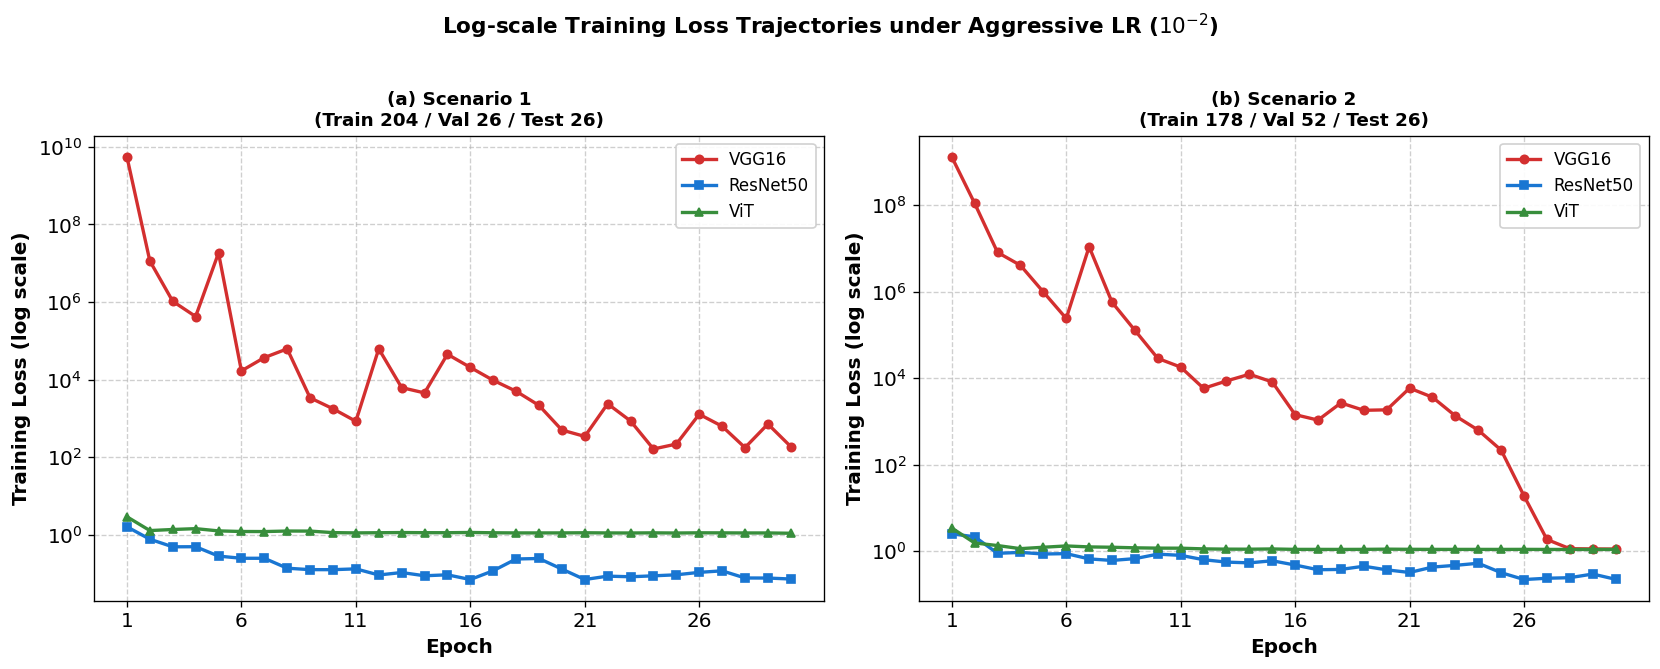

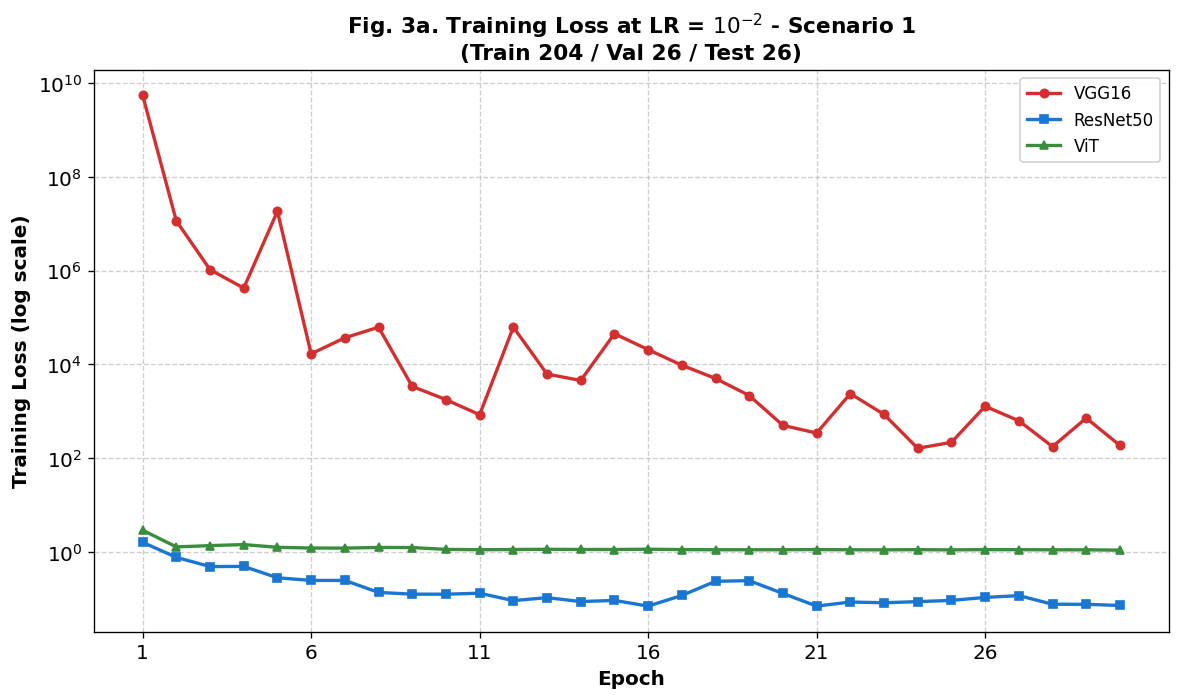

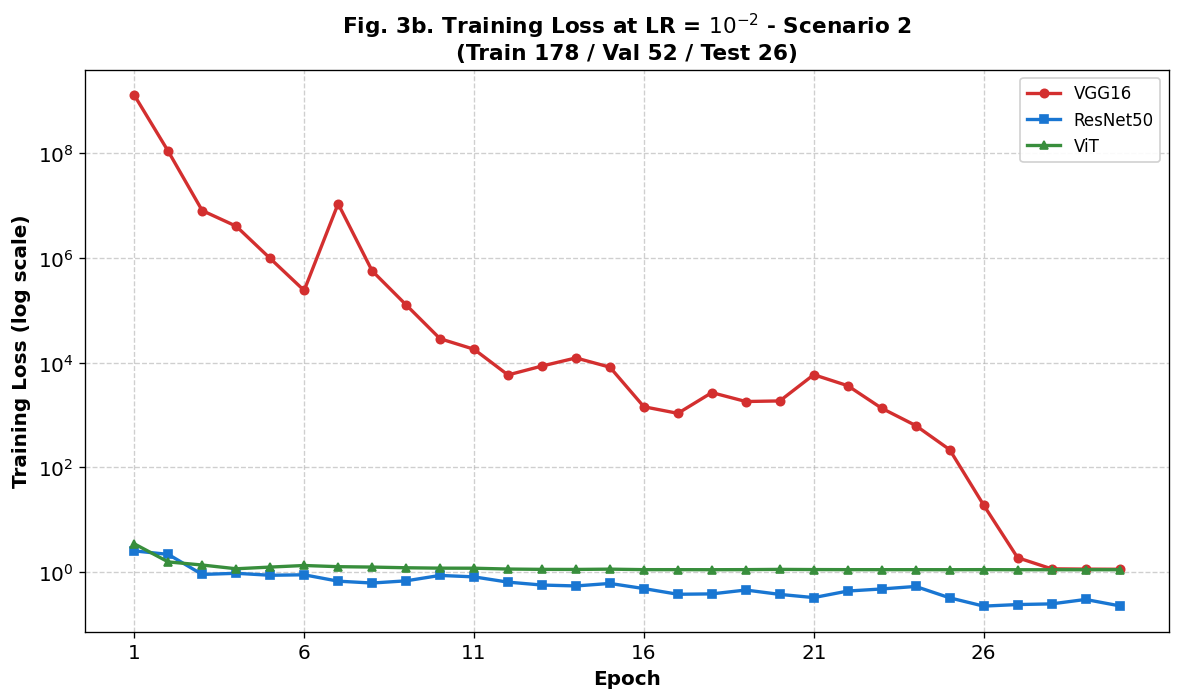

In [20]:
# ============================================================
# FIGURE 3 — Log-scale Training Loss at LR = 1e-2 (1x2 subplot)
# ============================================================
epochs = np.arange(1, 31)
colors = {'VGG16': '#D32F2F', 'ResNet50': '#1976D2', 'ViT': '#388E3C'}
markers = {'VGG16': 'o-', 'ResNet50': 's-', 'ViT': '^-'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

scenarios = [
    ('skenario_1', 0, '(a) Scenario 1', 'Train 204 / Val 26 / Test 26'),
    ('skenario_2', 1, '(b) Scenario 2', 'Train 178 / Val 52 / Test 26'),
]

for sk, idx, title, detail in scenarios:
    ax = axes[idx]
    data = METRICS[sk]['1e-2']
    for model in ['VGG16', 'ResNet50', 'ViT']:
        ax.plot(epochs, data[model]['train_loss'], markers[model],
                color=colors[model], linewidth=2, markersize=5, label=model)
    ax.set_yscale('log')
    ax.set_xlabel('Epoch', fontweight='bold')
    ax.set_ylabel('Training Loss (log scale)', fontweight='bold')
    ax.set_title(f'{title}\n({detail})', fontweight='bold', fontsize=11)
    ax.legend(framealpha=0.9)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_xticks(epochs[::5])

fig.suptitle(r'Log-scale Training Loss Trajectories under Aggressive LR ($10^{-2}$)',
             fontweight='bold', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('fig3_trainloss_1e2.png', dpi=150, bbox_inches='tight')
plt.show()

# Also save individual panels for backwards compatibility
for sk, idx, title, detail in scenarios:
    tag = 'skenario1' if sk == 'skenario_1' else 'skenario2'
    fig_i, ax_i = plt.subplots(figsize=(10, 6))
    data = METRICS[sk]['1e-2']
    for model in ['VGG16', 'ResNet50', 'ViT']:
        ax_i.plot(epochs, data[model]['train_loss'], markers[model],
                  color=colors[model], linewidth=2, markersize=5, label=model)
    ax_i.set_yscale('log')
    ax_i.set_xlabel('Epoch', fontweight='bold')
    ax_i.set_ylabel('Training Loss (log scale)', fontweight='bold')
    ax_i.set_title(f'Fig. 3{"a" if sk == "skenario_1" else "b"}. '
                   f'Training Loss at LR = $10^{{-2}}$ - {"Scenario 1" if sk == "skenario_1" else "Scenario 2"}\n'
                   f'({detail})', fontweight='bold')
    ax_i.legend(framealpha=0.9)
    ax_i.grid(True, linestyle='--', alpha=0.6)
    ax_i.set_xticks(epochs[::5])
    plt.tight_layout()
    plt.savefig(f'fig3{"a" if sk == "skenario_1" else "b"}_trainloss_1e2_{tag}.png',
                dpi=150, bbox_inches='tight')
    plt.show()


## Figure 4 — Validation Accuracy Trends under Optimal Learning Rate ($\mathbf{LR = 10^{-4}}$)

**Fig. 4.** Validation Accuracy Trends under Optimal Learning Rate (LR = $10^{-4}$).
Subfigures (a) Scenario 1 and (b) Scenario 2 highlight ViT's near-instantaneous
Epoch 1 convergence compared to ResNet50 and VGG16 progression.


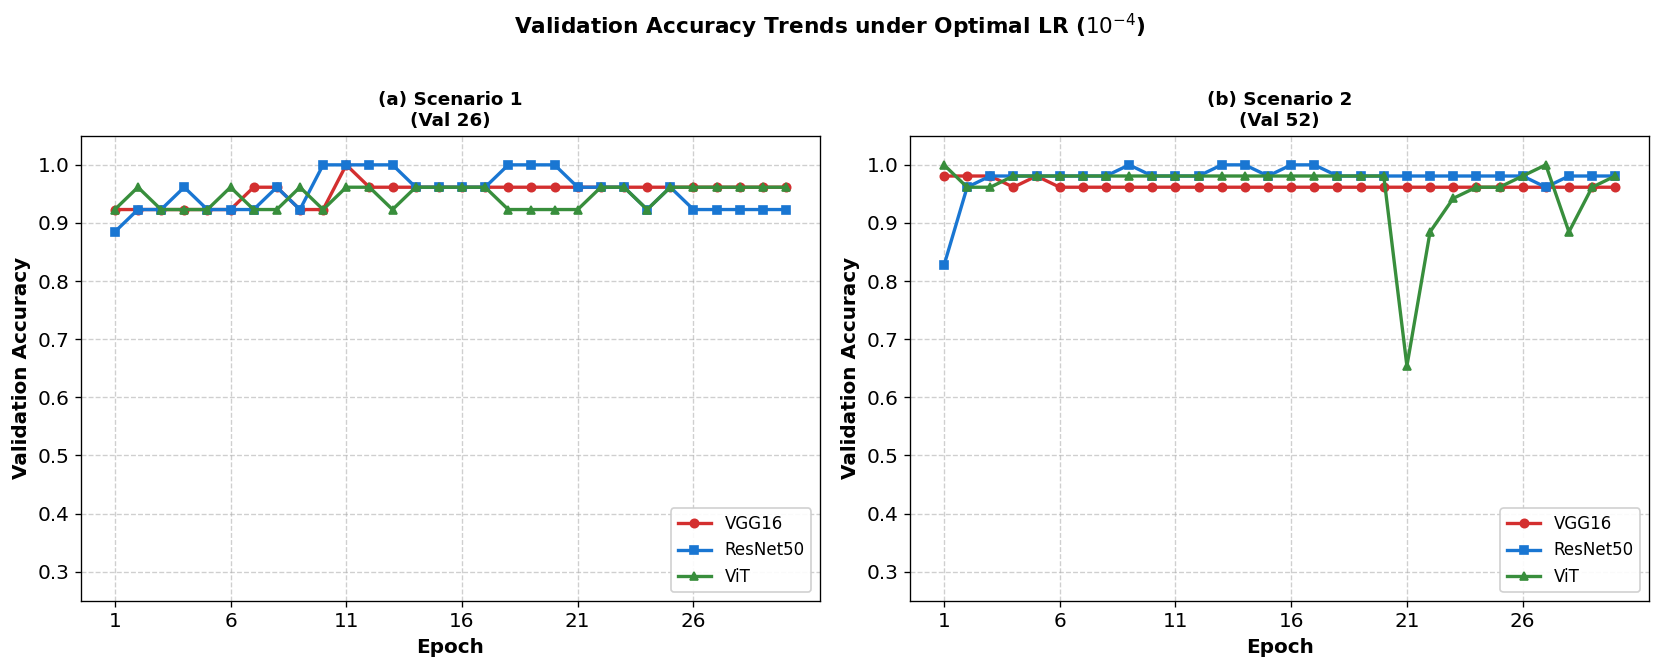

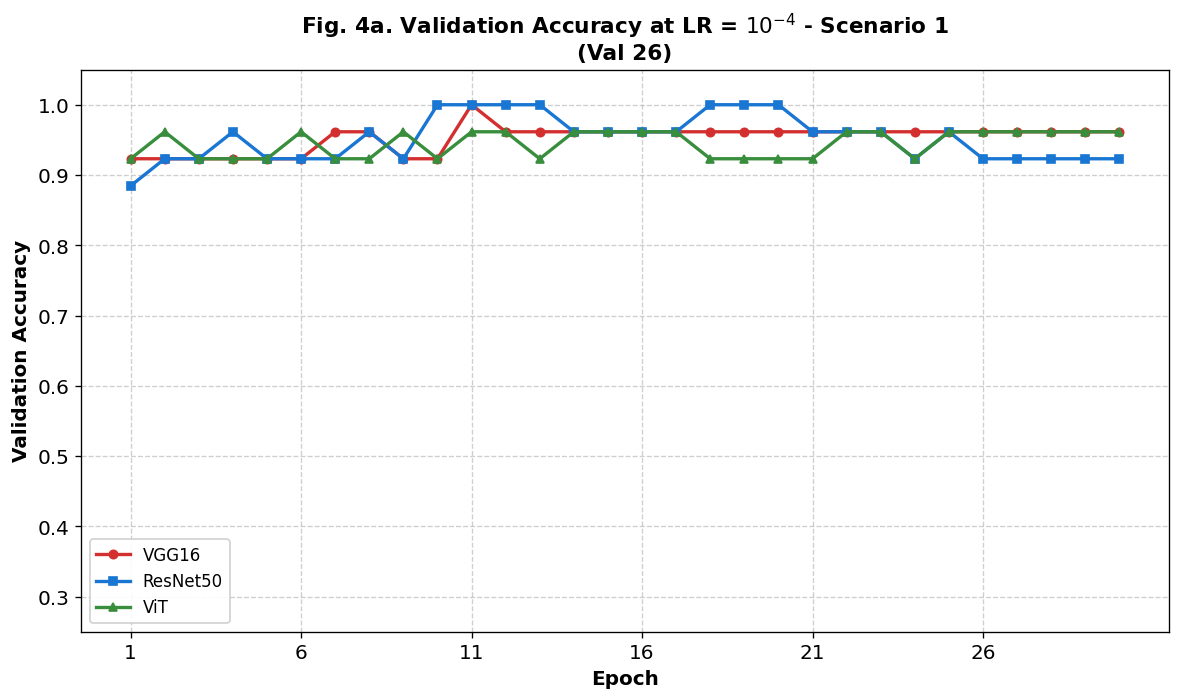

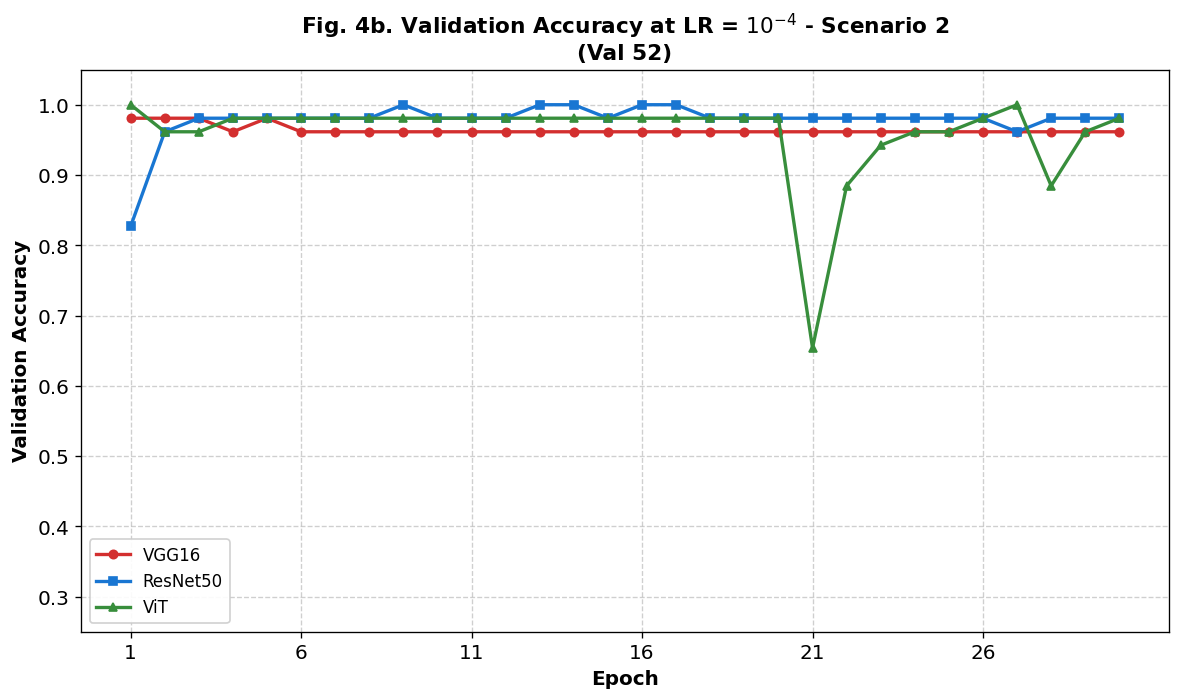

In [21]:
# ============================================================
# FIGURE 4 — Validation Accuracy at LR = 1e-4 (1x2 subplot)
# ============================================================
epochs = np.arange(1, 31)
colors = {'VGG16': '#D32F2F', 'ResNet50': '#1976D2', 'ViT': '#388E3C'}
markers = {'VGG16': 'o-', 'ResNet50': 's-', 'ViT': '^-'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

scenarios = [
    ('skenario_1', 0, '(a) Scenario 1', 'Val 26'),
    ('skenario_2', 1, '(b) Scenario 2', 'Val 52'),
]

for sk, idx, title, detail in scenarios:
    ax = axes[idx]
    data = METRICS[sk]['1e-4']
    for model in ['VGG16', 'ResNet50', 'ViT']:
        ax.plot(epochs, data[model]['val_acc'], markers[model],
                color=colors[model], linewidth=2, markersize=5, label=model)
    ax.set_xlabel('Epoch', fontweight='bold')
    ax.set_ylabel('Validation Accuracy', fontweight='bold')
    ax.set_title(f'{title}\n({detail})', fontweight='bold', fontsize=11)
    ax.legend(framealpha=0.9, loc='lower right')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_ylim(0.25, 1.05)
    ax.set_yticks(np.arange(0.3, 1.1, 0.1))
    ax.set_xticks(epochs[::5])

fig.suptitle(r'Validation Accuracy Trends under Optimal LR ($10^{-4}$)',
             fontweight='bold', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('fig4_valacc_1e4.png', dpi=150, bbox_inches='tight')
plt.show()

# Also save individual panels for backwards compatibility
for sk, idx, title, detail in scenarios:
    tag = 'skenario1' if sk == 'skenario_1' else 'skenario2'
    fig_i, ax_i = plt.subplots(figsize=(10, 6))
    data = METRICS[sk]['1e-4']
    for model in ['VGG16', 'ResNet50', 'ViT']:
        ax_i.plot(epochs, data[model]['val_acc'], markers[model],
                  color=colors[model], linewidth=2, markersize=5, label=model)
    ax_i.set_xlabel('Epoch', fontweight='bold')
    ax_i.set_ylabel('Validation Accuracy', fontweight='bold')
    ax_i.set_title(f'Fig. 4{"a" if sk == "skenario_1" else "b"}. '
                   f'Validation Accuracy at LR = $10^{{-4}}$ - {"Scenario 1" if sk == "skenario_1" else "Scenario 2"}\n'
                   f'({detail})', fontweight='bold')
    ax_i.legend(framealpha=0.9, loc='lower left')
    ax_i.grid(True, linestyle='--', alpha=0.6)
    ax_i.set_ylim(0.25, 1.05)
    ax_i.set_yticks(np.arange(0.3, 1.1, 0.1))
    ax_i.set_xticks(epochs[::5])
    plt.tight_layout()
    plt.savefig(f'fig4{"a" if sk == "skenario_1" else "b"}_valacc_1e4_{tag}.png',
                dpi=150, bbox_inches='tight')
    plt.show()


## Table II — Final Classification Metrics on the Unseen Test Set

**TABLE II.** Final classification metrics on the unseen test set (LR = $10^{-4}$).


In [22]:
# ===== TABLE II (Version 1) — Test Metrics at LR=1e-4 (Original) =====
data_v1 = {
    'Skenario': ['1', '1', '1', '2', '2', '2'],
    'Model':    ['ResNet50', 'VGG16', 'ViT',
                 'ResNet50', 'VGG16', 'ViT'],
    'Test Accuracy':  [0.9615, 0.9615, 0.9615, 0.9615, 0.9615, 0.9231],
    'Test Precision': [0.9654, 0.9654, 0.9654, 0.9654, 0.9654, 0.9231],
    'Test Recall':    [0.9615, 0.9615, 0.9615, 0.9615, 0.9615, 0.9231],
    'Test F1-Score':  [0.9614, 0.9614, 0.9614, 0.9614, 0.9614, 0.9231],
}
df_v1 = pd.DataFrame(data_v1)
df_v1 = df_v1.set_index(['Skenario', 'Model'])
display(Markdown('**Table II (v1). Final Test Metrics — LR = $10^{-4}$ (Test set fixed, random_state=42)**'))
display(df_v1)
print()
print("*Note: ResNet50 & VGG16 converge to identical test metrics (1 misclass: cancer → aneurysm). ViT sk.2 has 2 misclassifications (aneurysm ↔ cancer interchange).*")
print("*Per-class (ResNet50/VGG16): aneurysm (P=0.90, R=1.00, F1=0.95), tumor (P=1.00, R=1.00, F1=1.00), cancer (P=1.00, R=0.89, F1=0.94)*")
print("*Per-class (ViT sk.2):        aneurysm (P=0.89, R=0.89, F1=0.89), tumor (P=1.00, R=1.00, F1=1.00), cancer (P=0.89, R=0.89, F1=0.89)*")


**Table II (v1). Final Test Metrics — LR = $10^{-4}$ (Test set fixed, random_state=42)**

Test Accuracy  Test Precision  Test Recall  Test F1-Score
Skenario Model                                                              
1        ResNet50         0.9615          0.9654       0.9615         0.9614
         VGG16            0.9615          0.9654       0.9615         0.9614
         ViT              0.9615          0.9654       0.9615         0.9614
2        ResNet50         0.9615          0.9654       0.9615         0.9614
         VGG16            0.9615          0.9654       0.9615         0.9614
         ViT              0.9231          0.9231       0.9231         0.9231


*Note: ResNet50 & VGG16 converge to identical test metrics (1 misclass: cancer → aneurysm). ViT sk.2 has 2 misclassifications (aneurysm ↔ cancer interchange).*
*Per-class (ResNet50/VGG16): aneurysm (P=0.90, R=1.00, F1=0.95), tumor (P=1.00, R=1.00, F1=1.00), cancer (P=1.00, R=0.89, F1=0.94)*
*Per-class (ViT sk.2):        aneurysm (P=0.89, R=0.89, F1=0.89), tumor (P=1.00, R=1.00, F1=1.00), cancer (P=0.89, R=0.89, F1=0.89)*


In [23]:
# ===== TABLE II (Version 2) — With Validation Accuracy column =====
data_v2 = {
    'Skenario': ['1', '1', '1', '2', '2', '2'],
    'Model':    ['ResNet50', 'VGG16', 'ViT',
                 'ResNet50', 'VGG16', 'ViT'],
    'Test Accuracy':  [0.9615, 0.9615, 0.9615, 0.9615, 0.9615, 0.9231],
    'Test Precision': [0.9654, 0.9654, 0.9654, 0.9654, 0.9654, 0.9231],
    'Test Recall':    [0.9615, 0.9615, 0.9615, 0.9615, 0.9615, 0.9231],
    'Test F1-Score':  [0.9614, 0.9614, 0.9614, 0.9614, 0.9614, 0.9231],
    'Val Accuracy':   [0.9231, 0.9615, 0.9615,   # Skenario 1: Val 26
                       0.9615, 0.9615, 0.9615],  # Skenario 2: Val 52
}
df_v2 = pd.DataFrame(data_v2)
df_v2 = df_v2.set_index(['Skenario', 'Model'])
display(Markdown('**Table II (v2). Final Test Metrics + Validation Accuracy — LR = $10^{-4}$**'))
display(df_v2)
print()
print("*Note: Val Accuracy column (last epoch): Skenario 1 ResNet50 0.9231, VGG16/ViT 0.9615; Skenario 2 all 0.9615.*")


**Table II (v2). Final Test Metrics + Validation Accuracy — LR = $10^{-4}$**

Test Accuracy  Test Precision  Test Recall  Test F1-Score  \
Skenario Model                                                                 
1        ResNet50         0.9615          0.9654       0.9615         0.9614   
         VGG16            0.9615          0.9654       0.9615         0.9614   
         ViT              0.9615          0.9654       0.9615         0.9614   
2        ResNet50         0.9615          0.9654       0.9615         0.9614   
         VGG16            0.9615          0.9654       0.9615         0.9614   
         ViT              0.9231          0.9231       0.9231         0.9231   

                   Val Accuracy  
Skenario Model                   
1        ResNet50        0.9231  
         VGG16           0.9615  
         ViT             0.9615  
2        ResNet50        0.9615  
         VGG16           0.9615  
         ViT             0.9615


*Note: Val Accuracy column (last epoch): Skenario 1 ResNet50 0.9231, VGG16/ViT 0.9615; Skenario 2 all 0.9615.*


In [24]:
# ===== TABLE II (Version 3) — Test Metrics at LR=1e-2 (Model Failure Mode) =====
data_v3 = {
    'Skenario': ['1', '1', '1', '2', '2', '2'],
    'Model':    ['ResNet50', 'VGG16', 'ViT',
                 'ResNet50', 'VGG16', 'ViT'],
    'Test Accuracy':  [0.9231, 0.3462, 0.6538,    # S1
                       0.7308, 0.3462, 0.3462],   # S2
    'Test Precision': [0.9371, 0.1198, 0.4409,
                       0.8486, 0.1198, 0.1198],
    'Test Recall':    [0.9231, 0.3462, 0.6538,
                       0.7308, 0.3462, 0.3462],
    'Test F1-Score':  [0.9221, 0.1780, 0.5227,
                       0.6828, 0.1780, 0.1780],
}
df_v3 = pd.DataFrame(data_v3)
df_v3 = df_v3.set_index(['Skenario', 'Model'])
display(Markdown('**Table II (v3). Test Metrics — LR = $10^{-2}$ (Gradient Explosion Context)**'))
display(df_v3)
print()
print("*Note: LR=1e-2. VGG16 fails catastrophically (predicts only 'cancer'). ViT degrades from 0.6538 (sk.1) to majority-voting (sk.2).*")
print("*ResNet50 is the most robust architecture (0.9231 sk.1 / 0.7308 sk.2) but still significantly below LR=1e-4.*")


**Table II (v3). Test Metrics — LR = $10^{-2}$ (Gradient Explosion Context)**

Test Accuracy  Test Precision  Test Recall  Test F1-Score
Skenario Model                                                              
1        ResNet50         0.9231          0.9371       0.9231         0.9221
         VGG16            0.3462          0.1198       0.3462         0.1780
         ViT              0.6538          0.4409       0.6538         0.5227
2        ResNet50         0.7308          0.8486       0.7308         0.6828
         VGG16            0.3462          0.1198       0.3462         0.1780
         ViT              0.3462          0.1198       0.3462         0.1780


*Note: LR=1e-2. VGG16 fails catastrophically (predicts only 'cancer'). ViT degrades from 0.6538 (sk.1) to majority-voting (sk.2).*
*ResNet50 is the most robust architecture (0.9231 sk.1 / 0.7308 sk.2) but still significantly below LR=1e-4.*


## Figure 5 --- Grid Layout of Test Set Confusion Matrices at $\mathbf{LR = 10^{-4}}$

**Fig. 5.** Grid layout of test-set confusion matrices under the optimal
learning rate (LR = $10^{-4}$), arranged as 3 architectures (columns) $\times$
2 data-split scenarios (rows). The diagonal dominance confirms flawless
`tumor` identification across all six configurations, with errors heavily
localized to a single Cancer $\rightarrow$ Aneurysm sample. *Note:* the Skenario-2
ViT panel (bottom right) exhibits one additional Aneurysm $\rightarrow$ Cancer miss,
lowering its accuracy to 0.92. All remaining panels achieve 0.96.


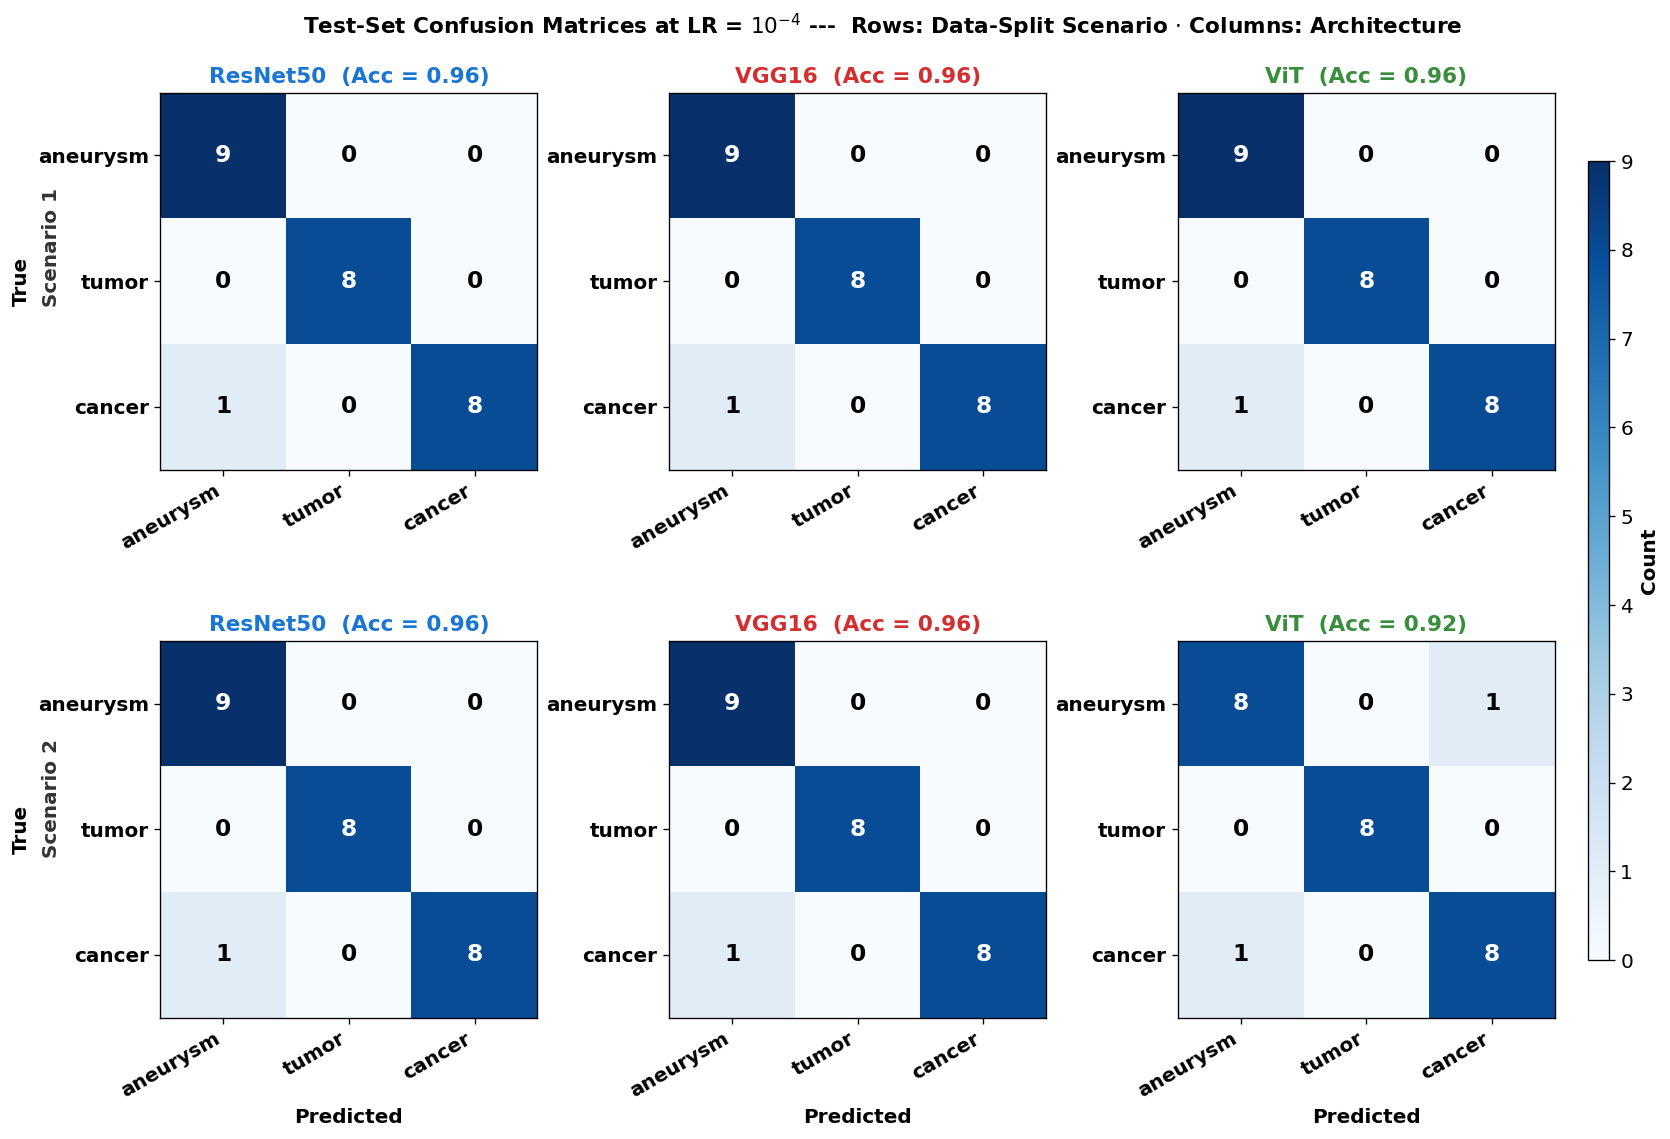

**Note:** In 5 of 6 configurations, errors are limited to a single sample of true `cancer` incorrectly predicted as `aneurysm`. The Skenario 2 / ViT panel additionally misclassifies one `aneurysm` sample as `cancer` (2 errors, Acc = 0.92). Tumor identification is flawless across all six panels.

In [25]:
# ===== FIGURE 5 --- Grid Layout of Test Set Confusion Matrices (LR = 1e-4) =====
import matplotlib.pyplot as plt
import numpy as np

class_names = ['aneurysm', 'tumor', 'cancer']

# ---- Hardcoded confusion matrices (rows = True, cols = Pred) ----
cms = {
    ('ResNet50', 1): np.array([[9, 0, 0], [0, 8, 0], [1, 0, 8]]),
    ('VGG16',    1): np.array([[9, 0, 0], [0, 8, 0], [1, 0, 8]]),
    ('ViT',      1): np.array([[9, 0, 0], [0, 8, 0], [1, 0, 8]]),
    ('ResNet50', 2): np.array([[9, 0, 0], [0, 8, 0], [1, 0, 8]]),
    ('VGG16',    2): np.array([[9, 0, 0], [0, 8, 0], [1, 0, 8]]),
    ('ViT',      2): np.array([[8, 0, 1], [0, 8, 0], [1, 0, 8]]),  # extra A->C error
}

models = ['ResNet50', 'VGG16', 'ViT']
scenarios = [1, 2]
colors = {'ResNet50': '#1976D2', 'VGG16': '#D32F2F', 'ViT': '#388E3C'}
scenario_info = {1: ('Scenario 1', ''), 2: ('Scenario 2', '')}

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 9))

for ri, sc in enumerate(scenarios):
    for ci, model in enumerate(models):
        ax = axes[ri, ci]
        cm = cms[(model, sc)]
        acc = np.trace(cm) / np.sum(cm)
        im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=9)

        # Annotate each cell
        for i in range(3):
            for j in range(3):
                val = cm[i, j]
                text_color = 'white' if val >= 5 else 'black'
                ax.text(j, i, str(val), ha='center', va='center',
                        fontsize=14, fontweight='bold', color=text_color)

        # Tick labels
        ax.set_xticks(range(3))
        ax.set_xticklabels(class_names, rotation=30, ha='right')
        ax.set_yticks(range(3))
        ax.set_yticklabels(class_names)

        # Axis labels only on edges
        if ri == 1:
            ax.set_xlabel('Predicted', fontweight='bold')
        if ci == 0:
            ax.set_ylabel('True', fontweight='bold')

        # Subplot title
        ax.set_title(f'{model}  (Acc = {acc:.2f})', fontweight='bold', color=colors[model])
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight('bold')

# ---- Row group labels ----
for ri, sc in enumerate(scenarios):
    name, detail = scenario_info[sc]
    y_pos = 0.78 if ri == 0 else 0.27
    fig.text(0.005, y_pos, f'{name}',
             rotation=90, va='center', ha='center', fontsize=12,
             fontweight='bold', color='#333333')

# ---- Suptitle ----
fig.suptitle(r'Test-Set Confusion Matrices at LR = $10^{-4}$ ---  Rows: Data-Split Scenario $\cdot$ Columns: Architecture',
             fontweight='bold', y=0.998, fontsize=13)

# ---- Colourbar ----
cbar_ax = fig.add_axes([0.92, 0.12, 0.012, 0.74])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Count', fontweight='bold')

# Tight layout
plt.subplots_adjust(left=0.07, right=0.90, top=0.93, bottom=0.06,
                    wspace=0.35, hspace=0.40)

plt.savefig('fig5_cm_grid_1e4.png', dpi=150, bbox_inches='tight')
plt.show()

display(Markdown('**Note:** In 5 of 6 configurations, errors are limited to a single sample'
    ' of true `cancer` incorrectly predicted as `aneurysm`. The Skenario 2 / ViT panel'
    ' additionally misclassifies one `aneurysm` sample as `cancer` (2 errors, Acc = 0.92).'
    ' Tumor identification is flawless across all six panels.'))
